In [6]:
require(tidyverse)
require(readxl)
require(DBI)
require(duckdb)

Loading required package: tidyverse
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors
Loading required package: readxl
Loading required package: DBI
Loading required package: duckdb


In [3]:
healthdata = read.csv("data/nhanes.csv")

In [7]:
healthdata |> tibble()

# A tibble: 20,293 × 78
      ID SurveyYr Gender   Age AgeMonths Race1    Race3 Education MaritalStatus HHIncome HHIncomeMid Poverty HomeRooms HomeOwn Work  Weight Length HeadCirc Height   BMI
   <int> <chr>    <chr>  <int>     <int> <chr>    <chr> <chr>     <chr>         <chr>          <int>   <dbl>     <int> <chr>   <chr>  <dbl>  <dbl>    <dbl>  <dbl> <dbl>
 1 51624 2009_10  male      34       409 White    NA    High Sch… Married       25000-3…       30000    1.36         6 Own     NotW…   87.4   NA         NA   165.  32.2
 2 51625 2009_10  male       4        49 Other    NA    NA        NA            20000-2…       22500    1.07         9 Own     NA      17     NA         NA   105.  15.3
 3 51626 2009_10  male      16       202 Black    NA    NA        NA            45000-5…       50000    2.27         5 Own     NotW…   72.3   NA         NA   181.  22  
 4 51627 2009_10  male      10       131 Black    NA    NA        NA            20000-2…       22500    0.81         6 Rent    NA  

In [8]:
health_conn <- dbConnect(duckdb())

In [9]:
duckdb_register(health_conn, 'healthdata', healthdata)

In [12]:
dbGetQuery(health_conn, "SELECT * FROM healthdata") |> tibble() 

# A tibble: 20,293 × 78
      ID SurveyYr Gender   Age AgeMonths Race1    Race3 Education MaritalStatus HHIncome HHIncomeMid Poverty HomeRooms HomeOwn Work  Weight Length HeadCirc Height   BMI
   <int> <chr>    <chr>  <int>     <int> <chr>    <chr> <chr>     <chr>         <chr>          <int>   <dbl>     <int> <chr>   <chr>  <dbl>  <dbl>    <dbl>  <dbl> <dbl>
 1 51624 2009_10  male      34       409 White    NA    High Sch… Married       25000-3…       30000    1.36         6 Own     NotW…   87.4   NA         NA   165.  32.2
 2 51625 2009_10  male       4        49 Other    NA    NA        NA            20000-2…       22500    1.07         9 Own     NA      17     NA         NA   105.  15.3
 3 51626 2009_10  male      16       202 Black    NA    NA        NA            45000-5…       50000    2.27         5 Own     NotW…   72.3   NA         NA   181.  22  
 4 51627 2009_10  male      10       131 Black    NA    NA        NA            20000-2…       22500    0.81         6 Rent    NA  

In [13]:
Clean_health_data = dbGetQuery(health_conn, "SELECT * FROM healthdata") |> tibble() 

In [14]:
Clean_health_data

# A tibble: 20,293 × 78
      ID SurveyYr Gender   Age AgeMonths Race1    Race3 Education MaritalStatus HHIncome HHIncomeMid Poverty HomeRooms HomeOwn Work  Weight Length HeadCirc Height   BMI
   <int> <chr>    <chr>  <int>     <int> <chr>    <chr> <chr>     <chr>         <chr>          <int>   <dbl>     <int> <chr>   <chr>  <dbl>  <dbl>    <dbl>  <dbl> <dbl>
 1 51624 2009_10  male      34       409 White    NA    High Sch… Married       25000-3…       30000    1.36         6 Own     NotW…   87.4   NA         NA   165.  32.2
 2 51625 2009_10  male       4        49 Other    NA    NA        NA            20000-2…       22500    1.07         9 Own     NA      17     NA         NA   105.  15.3
 3 51626 2009_10  male      16       202 Black    NA    NA        NA            45000-5…       50000    2.27         5 Own     NotW…   72.3   NA         NA   181.  22  
 4 51627 2009_10  male      10       131 Black    NA    NA        NA            20000-2…       22500    0.81         6 Rent    NA  

In [24]:
Clean_health_data |> 
  select(Gender, Race1, Age, MaritalStatus, Poverty, Weight) |> 
  filter(Age > 25 & MaritalStatus == 'Married' & Poverty != 'NA' & Weight != 'NA')

# A tibble: 4,979 × 6
   Gender Race1     Age MaritalStatus Poverty Weight
   <chr>  <chr>   <int> <chr>           <dbl>  <dbl>
 1 male   White      34 Married          1.36   87.4
 2 male   Mexican    26 Married          1.01   97.6
 3 male   White      80 Married          1.27   79.1
 4 female Black      42 Married          2.35  108. 
 5 male   Mexican    66 Married          0.41   82.9
 6 female White      45 Married          5      75.7
 7 male   White      66 Married          2.2    68  
 8 female Mexican    49 Married          1.45   76.5
 9 male   White      54 Married          2.2    74.7
10 female Mexican    26 Married          1.35  104. 
# ℹ 4,969 more rows
# ℹ Use `print(n = ...)` to see more rows

In [26]:
married_pp = Clean_health_data |> 
  select(Gender, Race1, Age, MaritalStatus, Poverty, Weight) |> 
  filter(Age > 25 & MaritalStatus == 'Married' & Poverty != 'NA' & Weight != 'NA')

In [27]:
married_pp

# A tibble: 4,979 × 6
   Gender Race1     Age MaritalStatus Poverty Weight
   <chr>  <chr>   <int> <chr>           <dbl>  <dbl>
 1 male   White      34 Married          1.36   87.4
 2 male   Mexican    26 Married          1.01   97.6
 3 male   White      80 Married          1.27   79.1
 4 female Black      42 Married          2.35  108. 
 5 male   Mexican    66 Married          0.41   82.9
 6 female White      45 Married          5      75.7
 7 male   White      66 Married          2.2    68  
 8 female Mexican    49 Married          1.45   76.5
 9 male   White      54 Married          2.2    74.7
10 female Mexican    26 Married          1.35  104. 
# ℹ 4,969 more rows
# ℹ Use `print(n = ...)` to see more rows

In [29]:
married_pp |> group_by(Race1) |> summarise(Clean_health_data = n(), Average_age = mean(Age), Maximum_age = max(Age), Minimum_age = min(Age)) 

# A tibble: 5 × 5
  Race1    Clean_health_data Average_age Maximum_age Minimum_age
  <chr>                <int>       <dbl>       <int>       <int>
1 Black                  774        53.0          80          26
2 Hispanic               423        50.8          80          26
3 Mexican                714        48.8          80          26
4 Other                  643        49.6          80          26
5 White                 2425        54.4          80          26

In [32]:
married_pp |> group_by(Race1) |> summarise(Clean_health_data = n(), Average_age = mean(Age), Maximum_age = max(Age), Minimum_age = min(Age)) -> wide_data

In [33]:
wide_data

# A tibble: 5 × 5
  Race1    Clean_health_data Average_age Maximum_age Minimum_age
  <chr>                <int>       <dbl>       <int>       <int>
1 Black                  774        53.0          80          26
2 Hispanic               423        50.8          80          26
3 Mexican                714        48.8          80          26
4 Other                  643        49.6          80          26
5 White                 2425        54.4          80          26

In [35]:
wide_data |> pivot_longer(c(Average_age, Maximum_age, Minimum_age), names_to = "Description", values_to = "values")

# A tibble: 15 × 4
   Race1    Clean_health_data Description values
   <chr>                <int> <chr>        <dbl>
 1 Black                  774 Average_age   53.0
 2 Black                  774 Maximum_age   80  
 3 Black                  774 Minimum_age   26  
 4 Hispanic               423 Average_age   50.8
 5 Hispanic               423 Maximum_age   80  
 6 Hispanic               423 Minimum_age   26  
 7 Mexican                714 Average_age   48.8
 8 Mexican                714 Maximum_age   80  
 9 Mexican                714 Minimum_age   26  
10 Other                  643 Average_age   49.6
11 Other                  643 Maximum_age   80  
12 Other                  643 Minimum_age   26  
13 White                 2425 Average_age   54.4
14 White                 2425 Maximum_age   80  
15 White                 2425 Minimum_age   26  

In [36]:
long_data = wide_data |> pivot_longer(c(Average_age, Maximum_age, Minimum_age), names_to = "Description", values_to = "values")

In [37]:
long_data

# A tibble: 15 × 4
   Race1    Clean_health_data Description values
   <chr>                <int> <chr>        <dbl>
 1 Black                  774 Average_age   53.0
 2 Black                  774 Maximum_age   80  
 3 Black                  774 Minimum_age   26  
 4 Hispanic               423 Average_age   50.8
 5 Hispanic               423 Maximum_age   80  
 6 Hispanic               423 Minimum_age   26  
 7 Mexican                714 Average_age   48.8
 8 Mexican                714 Maximum_age   80  
 9 Mexican                714 Minimum_age   26  
10 Other                  643 Average_age   49.6
11 Other                  643 Maximum_age   80  
12 Other                  643 Minimum_age   26  
13 White                 2425 Average_age   54.4
14 White                 2425 Maximum_age   80  
15 White                 2425 Minimum_age   26  

In [39]:
long_data |> pivot_wider(names_from = "Description", values_from = "values")

# A tibble: 5 × 5
  Race1    Clean_health_data Average_age Maximum_age Minimum_age
  <chr>                <int>       <dbl>       <dbl>       <dbl>
1 Black                  774        53.0          80          26
2 Hispanic               423        50.8          80          26
3 Mexican                714        48.8          80          26
4 Other                  643        49.6          80          26
5 White                 2425        54.4          80          26

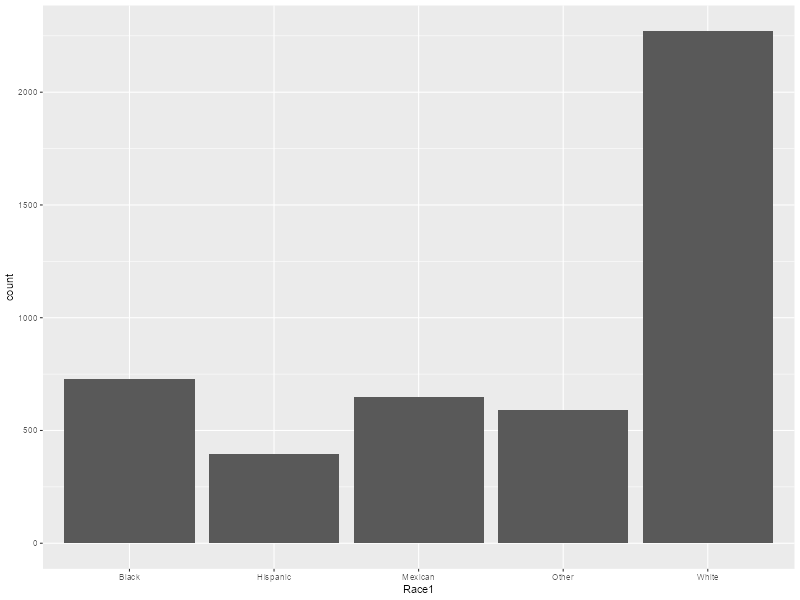

In [42]:
married_pp |> filter(Age > 30) |> ggplot() + aes(x = Race1) + geom_bar()

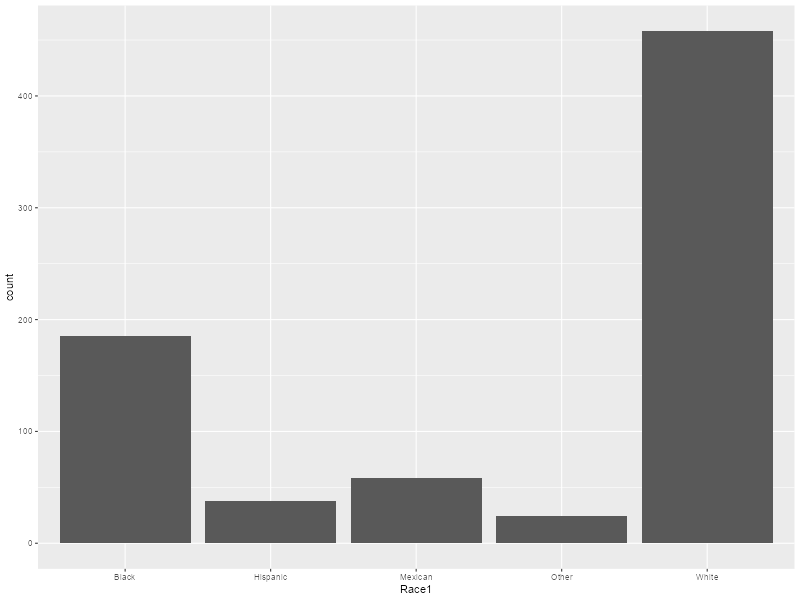

In [46]:
married_pp |> filter(Poverty > 3 & Weight > 90) |> ggplot() + aes(x = Race1) + geom_bar()